# Injury severity: gamma GLM vs. other models

How many days does an injury keep a player out? This notebook:
1. builds a modeling table from the database
2. groups injuries into **rating classes** (body region × injury type, with rare ones pooled)
3. picks **interactions** on a validation split
4. compares a **gamma GLM with a log link** (the standard actuarial severity model) against alternatives, on players the models never saw

The code is in `severity.py`. MySQL must be running, with the soccer data loaded, including appearances (`python build_db.py soccer data/football-datasets`). Soccer is the only source loaded so far that records how long injuries lasted. Career-ending injuries have their own yes/no model in `career_ending_model.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import severity as sev

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)

## 1. The modeling table

One row per injury. The response is `days_missed`. The table **leaves out**:
- injuries longer than 1,000 days: mostly careers that ended, which the career-ending model covers
- entries that aren't injuries ("Rest", "Fitness", suspensions)
- rows with an implausible age (younger than 15 or older than 45)

| Predictor | Why |
|---|---|
| `injury_class` | Rating class: body region × injury type, rare combinations pooled (section 2) |
| `age` (and age²) | Healing time changes with age, not necessarily in a straight line |
| `position_group` | Goalkeeper / Defender / Midfield / Attack |
| `prior_injuries` | Number of earlier injuries in the player's record |
| `reinjury_60d` | Injured within 60 days of returning from the previous injury |
| `prior_same_part` | Has hurt the same body part before (recurrence) |
| `log_mv` | Market value at the time of injury: how good the player is and how well-resourced his club is |
| `games_12m` | **Minutes played in the 12 months before the injury**, in full-game equivalents (minutes ÷ 90) |
| `career_games` | Career minutes before the injury, also ÷ 90 |
| `year` | Trend over time (medicine, and how thoroughly injuries were recorded) |
| `offseason` | Injured in June or July, so the time out includes the summer break |

**About the minutes.** Appearance data is per season, not per match, so a season counts only if it **ended before** the injury. Counting the current season would include games played after the injury, and a long injury means fewer of those, which would leak the answer into the predictor. Transfermarkt's own `minutes_played` column turned out to be *minutes per goal*. The loader converts it into real minutes, and estimates minutes from appearances for seasons without goals (the estimate is within 3% where it can be checked).

Injuries still open on the data date are kept but flagged `censored`. Only the Weibull model uses them.

In [2]:
data = sev.build_dataset("Soccer", max_days=1000)
train, test = sev.split(data)          # split by player: no player appears in both sets
print(f"{len(data):,} injuries, {data.pid.nunique():,} players, {data.censored.sum():,} still open, "
      f"{data.injury_class.nunique()} rating classes")
print(f"train {len(train):,}  /  test {len(test):,}")
data[["days_missed", "age", "games_12m", "career_games", "prior_injuries", "log_mv"]].describe().round(1).T

163,414 injuries, 34,429 players, 1,474 still open, 57 rating classes
train 130,324  /  test 33,090


,count,mean,std,min,25%,50%,75%,max
days_missed,163414.0,49.0,74.5,1.0,10.0,22.0,52.0,1000.0
age,163414.0,26.4,4.6,15.0,22.8,26.2,29.7,45.0
games_12m,163414.0,20.7,11.7,0.0,11.8,20.8,29.2,79.3
career_games,163414.0,163.4,117.5,0.0,72.5,141.5,232.0,960.9
prior_injuries,163414.0,5.0,6.4,0.0,1.0,3.0,7.0,71.0
log_mv,154627.0,13.8,1.8,9.2,12.4,13.6,15.0,19.1


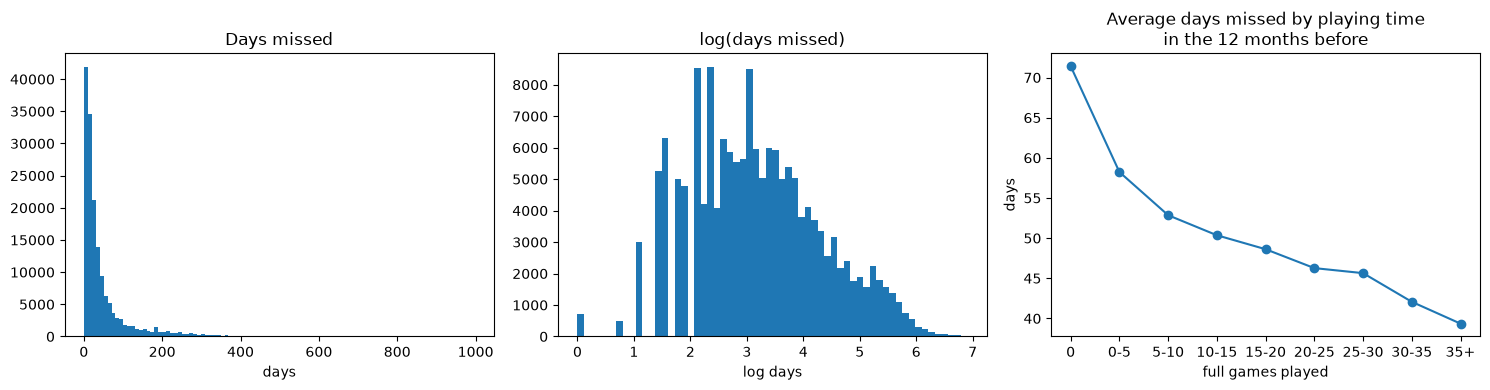

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
done = sev.completed(data)
ax[0].hist(done.days_missed, bins=100); ax[0].set(title="Days missed", xlabel="days")
ax[1].hist(np.log(done.days_missed), bins=60); ax[1].set(title="log(days missed)", xlabel="log days")
m = done.groupby(pd.cut(done.games_12m, [-1, 0, 5, 10, 15, 20, 25, 30, 35, 80]), observed=True).days_missed.mean()
ax[2].plot(range(len(m)), m.values, "o-"); ax[2].set_xticks(range(len(m)), ["0", "0-5", "5-10", "10-15", "15-20", "20-25", "25-30", "30-35", "35+"])
ax[2].set(title="Average days missed by playing time\nin the 12 months before", xlabel="full games played", ylabel="days")
plt.tight_layout()

Days missed are heavily right-skewed: most injuries are short, a few are very long. That shape is why a gamma (or lognormal, inverse Gaussian or Weibull) model fits and a normal linear regression doesn't.

Players with less recent playing time miss more days. Part of that is players coming back from an earlier long injury, and part is lower-tier players. Treat it as a risk factor, not a cause.

## 2. Rating classes: grouping rare injury types

Pricing needs every rating class to have enough injuries for a credible average. Each injury is placed in a cell of **body region × injury type**. A cell with at least **300** injuries is its own class, with a standard error of about 5% on its average at this spread. Rarer cells are pooled in this order:
1. **by injury type** across body regions, e.g. "Fracture - other sites"
2. if that's still too small, **by body region**, e.g. "Arm / hand - other types"
3. what's left goes into **"Other (rare)"**

Rare body parts were first merged with their anatomical neighbours: hand + wrist + elbow → arm / hand; chest + ribs + core → trunk; back + neck; quadriceps → thigh.

The classes are built from counts only, never from days missed, so building them on the full dataset doesn't leak test information.

In [4]:
sev.class_table(data)

,injuries,mean_days,median_days
injury_class,,,
Achilles - Tear / rupture,577,203.3,190.0
Knee - Tear / rupture,6541,190.4,191.0
Knee - Surgery,1742,166.5,150.0
Lower leg - Fracture,747,151.5,130.0
Fracture - other sites,362,123.0,101.5
Surgery - other sites,488,116.2,96.0
Ankle - Surgery,360,114.8,95.0
Knee - Ligament / joint,3323,110.9,63.0
Unknown - Fracture,1099,85.6,59.0


## 3. Choosing interactions

A GLM adds effects together on the log scale. An **interaction** lets one effect depend on another, for example letting age matter more for some body regions than others.

Candidates are tested by **forward selection on a validation split of the training data** (25% of training players), so the test set stays untouched until the final comparison. Each round adds the candidate that lowers validation gamma deviance most. Selection stops when no candidate improves it by at least 0.1%.

The first two rows show what the rating classes alone are worth, compared with the old separate body-part and injury-type effects. *This cell takes about 10 minutes.*

In [5]:
path, chosen = sev.select_interactions(train)
path

  added year x body region: validation deviance 0.9089


  added market value x injury type: validation deviance 0.9075


  added minutes (12 months) x body region: validation deviance 0.9064


,step,val_deviance,improvement_vs_previous
0,body part + injury type (main effects),0.93094,NaN
1,"rating classes (body region x injury type, rar...",0.91221,0.01874
2,+ year x body region,0.90886,0.00334
3,+ market value x injury type,0.90752,0.00134
4,+ minutes (12 months) x body region,0.90641,0.00112


In [6]:
print("Chosen:", chosen)

Chosen: ['year x body region', 'market value x injury type', 'minutes (12 months) x body region']


## 4. Fit the models

| Model | What it assumes |
|---|---|
| Gamma, no predictors | Every injury has the same expected days; the baseline every other model must beat |
| Gamma GLM, main effects | Separate body-part and injury-type effects, no interactions |
| **Gamma GLM, rating classes + interactions** | The model built in sections 2–3 |
| **Gamma GLM, severity tiers + interactions** | The same, with rating classes merged into severity tiers (section 7) |
| Inverse Gaussian GLM | Same predictors; variance grows with the mean³, so a heavier tail than gamma |
| Lognormal | Same predictors; log(days) is normal |
| Weibull AFT | Same predictors; a survival model that also learns from open injuries |
| Gradient boosting (gamma loss) | No formula; finds non-linear effects and interactions itself; an accuracy benchmark |

In [7]:
models = sev.fit_all(train, sev.default_models(chosen))

  fitting Gamma, no predictors ...


  fitting Gamma GLM, main effects ...


  fitting Gamma GLM, rating classes + interactions ...


  fitting Gamma GLM, severity tiers + interactions ...


  fitting Inverse Gaussian GLM ...


  fitting Lognormal (OLS on log days) ...


  fitting Weibull AFT (uses open injuries) ...


  fitting Gradient boosting (gamma loss) ...


## 5. Compare on held-out injuries

Every model is scored on completed injuries of test-set players:
- **log_lik:** average log-likelihood per injury; higher is better. It scores the whole predicted distribution, which is what pricing needs.
- **gamma_dev:** mean gamma deviance; lower is better.
- **mae / rmse:** error of the expected value, in days.
- **mean_pred:** average prediction. It should match the actual average, shown in the `(actual)` row.
- **above_p90:** share of injuries longer than the model's 90th percentile. If the tail is right, this is 10%.

In [8]:
sev.compare(models, test)

,log_lik,gamma_dev,mae,rmse,mean_pred,above_p90
model,,,,,,
"Gamma, no predictors",-4.8515,1.3912,44.02,70.97,48.24,0.1055
"Gamma GLM, main effects",-4.6143,0.9218,33.61,59.21,47.73,0.0907
"Gamma GLM, rating classes + interactions",-4.6009,0.9001,32.60,58.42,48.21,0.0896
"Gamma GLM, severity tiers + interactions",-4.6012,0.9007,32.65,58.49,48.18,0.0895
Inverse Gaussian GLM,-4.5917,0.9014,32.67,58.68,48.31,0.0855
Lognormal (OLS on log days),-4.5193,0.9137,32.82,59.96,49.32,0.0958
Weibull AFT (uses open injuries),-4.6145,0.9019,33.06,58.56,49.51,0.0797
Gradient boosting (gamma loss),NaN,0.8807,31.89,57.86,46.92,NaN
(actual),NaN,NaN,NaN,NaN,47.51,NaN


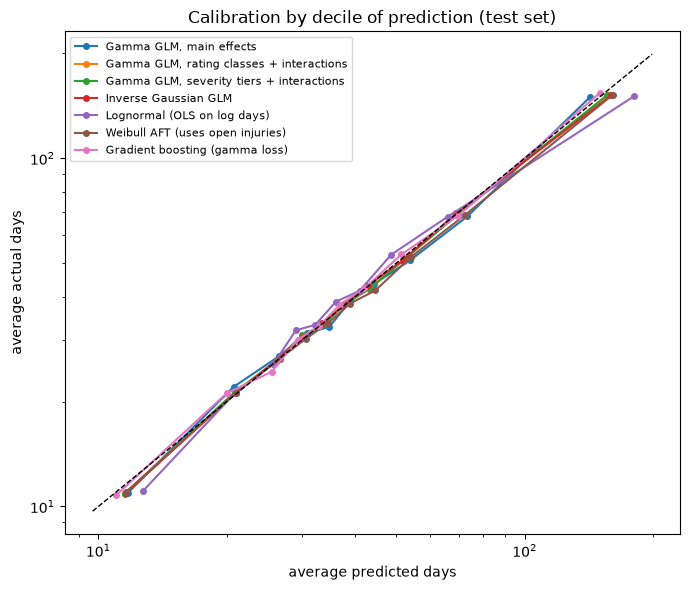

In [9]:
cal = sev.calibration(models, test)
fig, ax = plt.subplots(figsize=(7, 6))
for name, g in cal.groupby("model", sort=False):
    ax.plot(g.pred, g.actual, "o-", ms=4, label=name)
lim = [cal[["pred", "actual"]].min().min() * 0.9, cal[["pred", "actual"]].max().max() * 1.1]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlabel="average predicted days", ylabel="average actual days",
       title="Calibration by decile of prediction (test set)")
ax.legend(fontsize=8)
plt.tight_layout()

### Does the distribution fit? (PIT histograms)

For each test injury, take the model's predicted probability that an injury would be *this short or shorter*. If the model's distribution is right, these values are spread evenly between 0 and 1, giving a flat histogram.
- **U shape:** the spread is too narrow.
- **Hump in the middle:** the spread is too wide.
- **Spike at 1:** more very long injuries than the model allows.

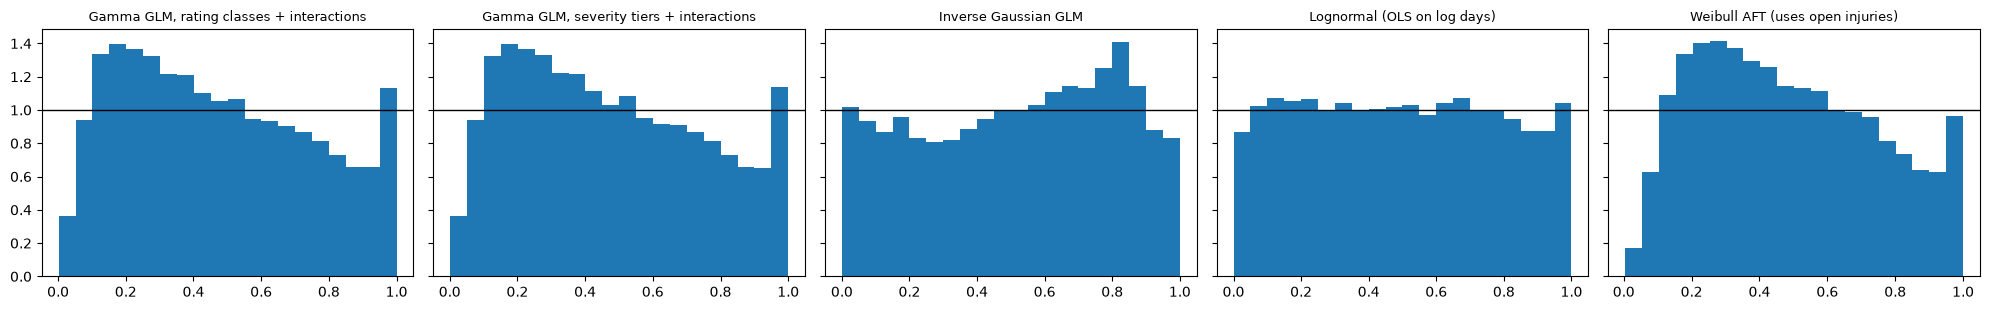

In [10]:
dist_models = {n: m for n, m in models.items() if hasattr(m, "cdf") and n not in ("Gamma, no predictors", "Gamma GLM, main effects")}
done_test = sev.completed(test)
fig, axes = plt.subplots(1, len(dist_models), figsize=(4 * len(dist_models), 3.2), sharey=True)
for ax, (name, m) in zip(axes, dist_models.items()):
    ax.hist(m.cdf(done_test), bins=20, density=True)
    ax.axhline(1, color="k", lw=1)
    ax.set_title(name, fontsize=9)
plt.tight_layout()

## 6. Gamma GLM relativities

With a log link, `exp(coefficient)` multiplies the expected days missed. The reference injury is an unspecified hamstring injury to a 26-year-old midfielder in 2015, outside the offseason, worth €500k, with no injury history.

- **Rating classes:** the `injury_class = …` rows are the rating table for injury type.
- **Interactions:** the interaction rows adjust a main effect for one group. For example, `year_c x region = Knee` is the extra yearly trend for knee injuries on top of the overall `year_c` trend.

In [11]:
rel = sev.relativities(models["Gamma GLM, rating classes + interactions"])
rel[rel.index.str.startswith("injury_class") | ~rel.index.str.contains(" x ")]

,multiplier,ci_low,ci_high,p_value
Intercept,69.2678,60.4818,79.3301,0.0000
injury_class = Achilles - Tear / rupture,3.0143,2.4013,3.7836,0.0000
injury_class = Achilles - Tendon / inflammation,0.9020,0.7264,1.1199,0.3502
injury_class = Ankle (unspecified),1.0223,0.8744,1.1952,0.7817
injury_class = Ankle - Ligament / joint,0.6534,0.5512,0.7745,0.0000
injury_class = Ankle - Surgery,2.7196,2.1888,3.3792,0.0000
injury_class = Ankle - Tear / rupture,1.3340,1.1280,1.5775,0.0008
injury_class = Arm / hand (unspecified),0.8812,0.6866,1.1309,0.3205
injury_class = Arm / hand - Fracture,1.0071,0.7835,1.2944,0.9562
injury_class = Back / neck (unspecified),1.3543,1.0936,1.6772,0.0054


In [12]:
rel[rel.index.str.contains(" x ")]

,multiplier,ci_low,ci_high,p_value
log_mv_c x nature = Concussion,0.9896,0.9309,1.0520,0.7372
log_mv_c x nature = Fracture,1.0267,1.0020,1.0520,0.0340
log_mv_c x nature = Knock / bruise,0.9635,0.9458,0.9814,0.0001
log_mv_c x nature = Ligament / joint,0.9873,0.9658,1.0093,0.2552
log_mv_c x nature = Strain / muscle,1.0183,1.0051,1.0316,0.0064
log_mv_c x nature = Surgery,1.0203,0.9892,1.0523,0.2033
log_mv_c x nature = Tear / rupture,1.0617,1.0452,1.0784,0.0000
log_mv_c x nature = Tendon / inflammation,0.9784,0.9494,1.0082,0.1536
log(1 + games_12m) x region = Achilles,1.1203,1.0492,1.1963,0.0007
log(1 + games_12m) x region = Ankle,1.0000,0.9532,1.0490,0.9985


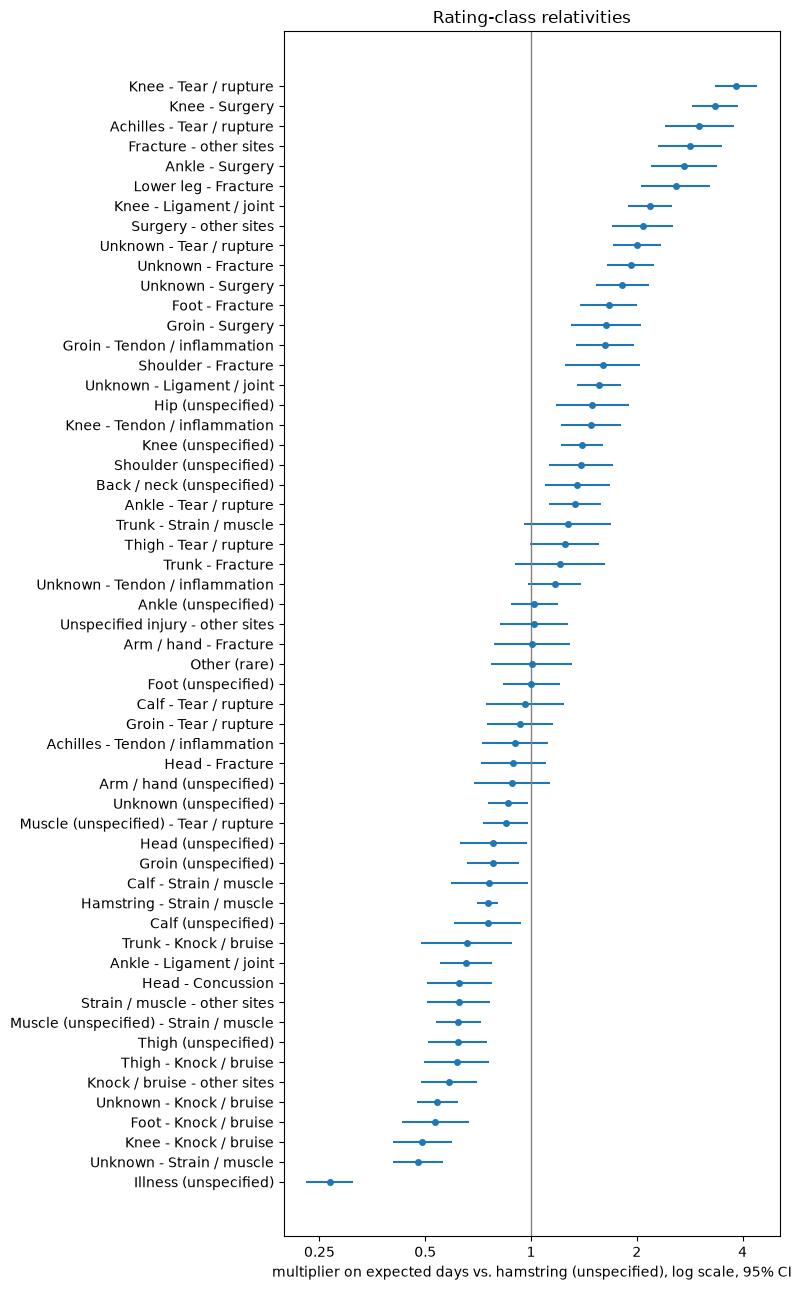

In [13]:
r = rel[rel.index.str.startswith("injury_class")].sort_values("multiplier")
fig, ax = plt.subplots(figsize=(8, 13))
ax.errorbar(r.multiplier, r.index.str.replace("injury_class = ", ""), xerr=[r.multiplier - r.ci_low, r.ci_high - r.multiplier], fmt="o", ms=4)
ax.axvline(1, color="grey", lw=1)
ax.set(xscale="log", xlabel="multiplier on expected days vs. hamstring (unspecified), log scale, 95% CI",
       title="Rating-class relativities")
ticks = [0.25, 0.5, 1, 2, 4]
ax.set_xticks(ticks, [f"{t:g}" for t in ticks]); ax.minorticks_off()
plt.tight_layout()

## 7. Severity tiers: merging classes that can't be told apart

Many of the 57 rating classes have overlapping confidence intervals in section 6. The data can't distinguish them, so a rating table doesn't need them all. `severity_tiers()` merges them:

1. Order the classes by their relativity, with all the other predictors in the model.
2. Merge neighbouring groups, least different pair first, while the difference between them is not statistically significant (p > 0.05).
3. Refit the model with the merged groups and repeat until every pair of neighbouring tiers differs significantly.

The tiers are built from the **training data only**. Unlike the rating classes, they depend on the outcome, so building them from all the data would flatter the test score. The multipliers are relative to the tier that contains the reference injury (an unspecified hamstring injury). Average and median days are observed in the training data.

In [14]:
tiered = models["Gamma GLM, severity tiers + interactions"]
tiers = tiered.tier_table(train)
print(f"{len(tiers)} tiers from {data.injury_class.nunique()} rating classes")
tiers

11 tiers from 57 rating classes


,injuries,mean_days,median_days,multiplier,ci_low,ci_high,classes
severity_tier,,,,,,,
Tier 1,11051,11.2,8.0,0.264,0.238,0.293,Illness (unspecified)
Tier 2,6255,20.2,11.0,0.531,0.503,0.560,Foot - Knock / bruise; Knee - Knock / bruise; ...
Tier 3,18668,26.2,17.0,0.628,0.599,0.657,Ankle - Ligament / joint; Head - Concussion; K...
Tier 4,10859,32.3,20.0,0.750,0.714,0.787,Calf (unspecified); Calf - Strain / muscle; Gr...
Tier 5,34764,37.1,21.0,0.867,0.830,0.905,Achilles - Tendon / inflammation; Arm / hand (...
Tier 6,14004,43.9,28.0,1.000,1.000,1.000,Ankle (unspecified); Arm / hand - Fracture; Fo...
Tier 7,14444,58.9,31.0,1.304,1.245,1.366,Ankle - Tear / rupture; Back / neck (unspecifi...
Tier 8,5753,67.6,43.0,1.565,1.486,1.649,Foot - Fracture; Groin - Surgery; Groin - Tend...
Tier 9,5161,99.7,62.0,2.003,1.898,2.113,Knee - Ligament / joint; Surgery - other sites...


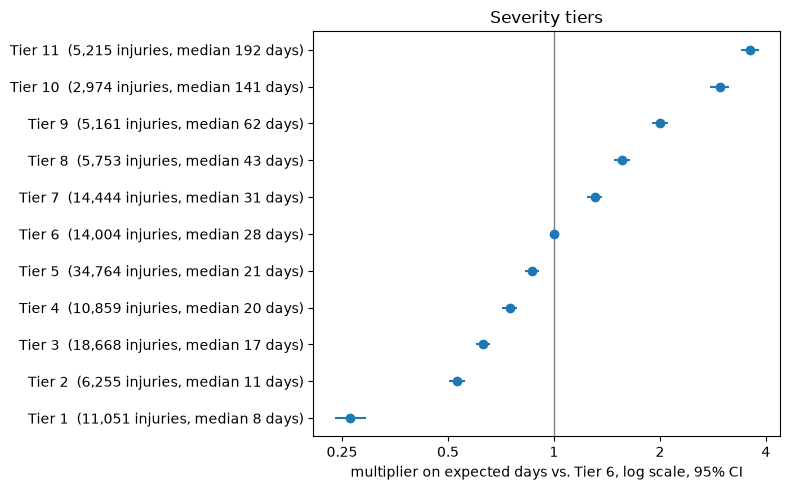

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(tiers))
ax.errorbar(tiers.multiplier, y, xerr=[tiers.multiplier - tiers.ci_low, tiers.ci_high - tiers.multiplier], fmt="o", ms=6)
ax.set_yticks(list(y), [f"{t}  ({n:,} injuries, median {m:.0f} days)" for t, n, m in zip(tiers.index, tiers.injuries, tiers.median_days)])
ax.axvline(1, color="grey", lw=1)
ticks = [0.25, 0.5, 1, 2, 4]
ax.set(xscale="log", xlabel=f"multiplier on expected days vs. {tiered.ref_tier}, log scale, 95% CI", title="Severity tiers")
ax.set_xticks(ticks, [f"{t:g}" for t in ticks]); ax.minorticks_off()
plt.tight_layout()

In [16]:
sev.compare({k: models[k] for k in ["Gamma GLM, rating classes + interactions", "Gamma GLM, severity tiers + interactions"]}, test)

,log_lik,gamma_dev,mae,rmse,mean_pred,above_p90
model,,,,,,
"Gamma GLM, rating classes + interactions",-4.6009,0.9001,32.60,58.42,48.21,0.0896
"Gamma GLM, severity tiers + interactions",-4.6012,0.9007,32.65,58.49,48.18,0.0895
(actual),NaN,NaN,NaN,NaN,47.51,NaN


## Reading the results

These numbers come from the run saved here. Splits use fixed seeds, so re-running gives the same results.

**What improved the gamma GLM** (validation gamma deviance, lower is better; section 3):
1. **Rating classes** were by far the biggest gain: 0.931 → 0.912, or 2% better than separate body-part and injury-type effects. A knee *tear* and a knee *knock* now get their own relativities (×3.8 vs. ×0.5) instead of one shared "knee" effect.
2. **Three interactions** improved it another 0.6% (0.912 → 0.906): year × body region, market value × injury type, and minutes in the past year × body region.

The other nine candidates didn't clear the 0.1% bar, including age × body region and position × body region.

**On the test set** (section 5), the final gamma GLM improves on the main-effects version:
- gamma deviance 0.922 → 0.900
- mean absolute error 33.6 → 32.6 days

That closes about half the gap to gradient boosting (0.881), which is the accuracy you could get with no formula at all. The GLM keeps a rating table you can explain and file.

**The shape of the distribution hasn't changed.** The lognormal still fits the whole distribution best: it has the highest log-likelihood (−4.52 vs. −4.60 for the gamma), the flattest PIT histogram, and 9.6% of injuries above its 90th percentile. The gamma still predicts too many very short injuries and has a thin right tail: the gap near 0 and the spike at 1 in its PIT histogram. All models get the *average* right (the calibration plot).

**Severity tiers (section 7).** Merging classes that can't be told apart turns the 57 rating classes into **11 tiers** with almost no loss of accuracy: test deviance is 0.9007 against 0.9001 for the full classes. Every tier's 95% interval is separate from its neighbours'. The tiers run from illness on its own (×0.26 of the reference tier, median 8 days) to knee tears on their own (×3.6, median 192 days). Achilles tears, knee surgery, ankle surgery and lower-leg fractures share the tier below (×3.0). This is the version to file as a rating table: 11 rows instead of 57.

So:
- **For expected cost:** use the gamma GLM with severity tiers; its relativities are the rating table.
- **For anything that depends on the tail:** policy limits, deductibles measured in days, or the probability of missing more than N days. Fit the same predictors with a lognormal.

**What the effects say:**
- **Rating classes:** knee tear ×3.8, knee surgery ×3.3, Achilles tear ×3.0, ankle surgery ×2.7, lower-leg fracture ×2.6; knocks about ×0.5 and illness ×0.27, all relative to an unspecified hamstring injury. Many mid-table classes have overlapping confidence intervals. Section 7 merges those into severity tiers.
- **Minutes before the injury:** more playing time in the past year means a slightly shorter injury overall (×0.93 per log unit). The interaction shows the opposite for **Achilles (×1.12)** and **lower-leg (×1.09)** injuries, where heavy workloads go with longer layoffs, consistent with overuse injuries. Back, head and trunk injuries go the other way.
- **Market value × injury type:** for expensive players, tears take *longer* (×1.06 per log unit of value) and knocks shorter. Big clubs bring stars back from serious injuries more cautiously.
- **Time trend:** durations rise about 1.9% per year overall. Illness, hip, groin and unclassified injuries are getting relatively shorter.
- **Offseason:** injuries in June or July run 28% longer because the time out includes the summer break.
- **Recurrence:** re-injuring the same body part adds about 8%, and getting hurt again within 60 days of returning adds about 5%.
- **Age:** a small effect that peaks around age 31.
- **Effects that reflect record-keeping:** players with more recorded injuries, or a higher market value, have shorter injuries on average. Top-league clubs report minor knocks that lower leagues never record. Keep these as controls, but don't read them as causes.

**Career-ending injuries** (over 1,000 days, or never returning) are modeled separately in `career_ending_model.ipynb`.